# ✈️ Flight Delays and Cancellations | Clustering de Perfis de Atraso

**Entrada:** `flights_features.parquet`  
**Saída:** modelo de clustering em `models/kmeans`

## Objetivo

Identificar **perfis de atraso** — grupos de voos que compartilham um padrão
semelhante quanto às causas do atraso (problema de voo, clima, companhia, etc.).

## Escopo

- Somente voos **atrasados** (`LABEL = 1`, atraso ≥ 15 min) são agrupados.
  Para voos pontuais todas as colunas de causa valem 0 — incluí-los criaria
  um cluster trivial sem informação.
- **Features de agrupamento**: as 5 colunas de causa de atraso
  (`AIR_SYSTEM`, `SECURITY`, `AIRLINE`, `LATE_AIRCRAFT`, `WEATHER`).
- **Algoritmo**: K-Means — escalável no Spark, interpretável e adequado
  quando os clusters esperados são convexos (perfis de causa bem separados).
- **K ótimo**: determinado pela combinação de curva de cotovelo (WSSSE)
  e coeficiente de silhueta.

## Imports e Configurações

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator


In [5]:
os.environ['JAVA_HOME'] = "/usr/lib/jvm/java-17-openjdk-amd64"
spark = (
    SparkSession.builder
        .appName("Clustering")
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.repl.eagerEval.enabled", True)
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("="*80)
print(f"✅ Spark Session ...\n\tSpark Version: {spark.version}\n\tPython Version: {sys.version}")
print("="*80)


✅ Spark Session ...
	Spark Version: 4.1.1
	Python Version: 3.13.5 (main, Jun 11 2025, 15:36:57) [GCC 11.4.0]


## Carregamento dos Dados

In [6]:
df = spark.read.parquet('../data/processed/flights_features.parquet')
df.cache()

print(f'Total de registros : {df.count():,}')
print(f'Colunas disponíveis: {len(df.columns)}')
print('\nDistribuição LABEL:')
df.groupBy('LABEL').count()\
  .withColumn('PCT', F.round(F.col('count') / df.count() * 100, 2))\
  .orderBy('LABEL').show()


26/04/05 22:01:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Total de registros : 5,714,008
Colunas disponíveis: 30

Distribuição LABEL:
+-----+-------+-----+
|LABEL|  count|  PCT|
+-----+-------+-----+
|    0|4650569|81.39|
|    1|1063439|18.61|
+-----+-------+-----+



## Preparação dos Dados

### Filtragem: apenas voos atrasados

Voos pontuais têm todas as colunas de causa = 0 (preenchidas na etapa de
feature engineering). Incluí-los geraria um cluster trivial dominante e
prejudicaria a qualidade do agrupamento.

In [7]:
df_delayed = df.filter(F.col('LABEL') == 1)

n_delayed = df_delayed.count()
n_total   = df.count()
print(f'Voos atrasados : {n_delayed:>9,}  ({n_delayed/n_total*100:.1f}% do total)')

Voos atrasados : 1,063,439  (18.6% do total)


### Agrupamento de Características

As 4 colunas de causas de atraso (minutos que cada causa contribuiu para o atraso):

| Característica | Descrição |
|---|---|
| `AIR_SYSTEM_DELAY` | Congestionamento do espaço aéreo, fechamento de pista |
| `AIRLINE_DELAY` | Manutenção, tripulação, limpeza, embarque |
| `LATE_AIRCRAFT_DELAY` | Aeronave chegou atrasada à origem (efeito cascata) |
| `WEATHER_DELAY` | Condições meteorológicas adversas |

> `SECURITY_DELAY` excluída: média < 0,1 min em todos os voos — variância próxima de zero adiciona ruído.

In [8]:
FEATURES_CLUSTER = [
    'AIR_SYSTEM_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
]

df_delayed = df_delayed.fillna(0, subset=FEATURES_CLUSTER)

print('Descriptive statistics:')
df_delayed.select(FEATURES_CLUSTER).describe().show()

Descriptive statistics:
+-------+------------------+------------------+-------------------+-----------------+
|summary|  AIR_SYSTEM_DELAY|     AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|    WEATHER_DELAY|
+-------+------------------+------------------+-------------------+-----------------+
|  count|           1063439|           1063439|            1063439|          1063439|
|   mean|13.480568231934319|18.969546913363153| 23.472837652183152|2.915289922600168|
| stddev|28.003678900236345| 48.16164189832559| 43.197018477241116|20.43333571763138|
|    min|               0.0|               0.0|                0.0|              0.0|
|    max|            1134.0|            1971.0|             1331.0|           1211.0|
+-------+------------------+------------------+-------------------+-----------------+



## Pré-processamento

K-Means usa distância euclidiana — features com escalas diferentes dominam
o cálculo. Aplicamos `StandardScaler` (média=0, desvio=1) para equalizar
a influência de cada causa.

> O `StandardScaler` é ajustado **sobre todos os voos atrasados** (não há
> divisão treino/teste em clustering não supervisionado).

In [9]:
assembler = VectorAssembler(
    inputCols=FEATURES_CLUSTER,
    outputCol='features_raw',
    handleInvalid='keep'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)

pipeline_prep = Pipeline(stages=[assembler, scaler])
prep_model    = pipeline_prep.fit(df_delayed)
df_scaled     = prep_model.transform(df_delayed)
df_scaled.cache()

print(f'Dataset preparado: {df_scaled.count():,} registros')
print('Pré-processamento concluído ✅')


Dataset preparado: 1,063,439 registros
Pré-processamento concluído ✅


## Escolha do K

Duas métricas complementares são avaliadas para K ∈ [2, 8]:

- **WSSSE** *(Within-Cluster Sum of Squared Errors)*: mede a compactação
  interna. Decresce monotonicamente — o K ótimo é o "cotovelo" onde a
  redução marginal se torna desprezível.
- **Coeficiente de Silhueta**: mede quão bem cada ponto está alocado ao
  seu cluster em relação aos demais. Varia de -1 (ruim) a +1 (ótimo).

Para agilizar a busca, as métricas são calculadas sobre uma **amostra
estratificada de 10%** (≈ 100 mil registros). O modelo final será treinado
no dataset completo.

In [10]:
df_sample = df_scaled.sample(fraction=0.10, seed=42)
df_sample.cache()
print(f'Tamanho da amostra: {df_sample.count():,} registros')

silhouette_eval = ClusteringEvaluator(
    featuresCol='features',
    predictionCol='prediction',
    metricName='silhouette'
)

resultados_k = []

for k in range(2, 9):
    km = KMeans(featuresCol='features', k=k, seed=42, maxIter=30)
    m  = km.fit(df_sample)
    pred = m.transform(df_sample)

    wssse      = round(m.summary.trainingCost, 2)
    silhouette = round(silhouette_eval.evaluate(pred), 4)

    resultados_k.append({'k': k, 'WSSSE': wssse, 'Silhueta': silhouette})
    print(f'  k={k}  |  WSSSE={wssse:>14,.2f}  |  Silhueta={silhouette:.4f}')

df_k = pd.DataFrame(resultados_k)


Tamanho da amostra: 106,179 registros


26/04/05 22:02:50 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


  k=2  |  WSSSE=    359,457.45  |  Silhueta=0.9373
  k=3  |  WSSSE=    292,178.93  |  Silhueta=0.6152
  k=4  |  WSSSE=    232,074.02  |  Silhueta=0.6800
  k=5  |  WSSSE=    208,070.50  |  Silhueta=0.2031
  k=6  |  WSSSE=    157,178.03  |  Silhueta=0.6041
  k=7  |  WSSSE=    138,932.20  |  Silhueta=0.5417
  k=8  |  WSSSE=    127,049.74  |  Silhueta=0.7134


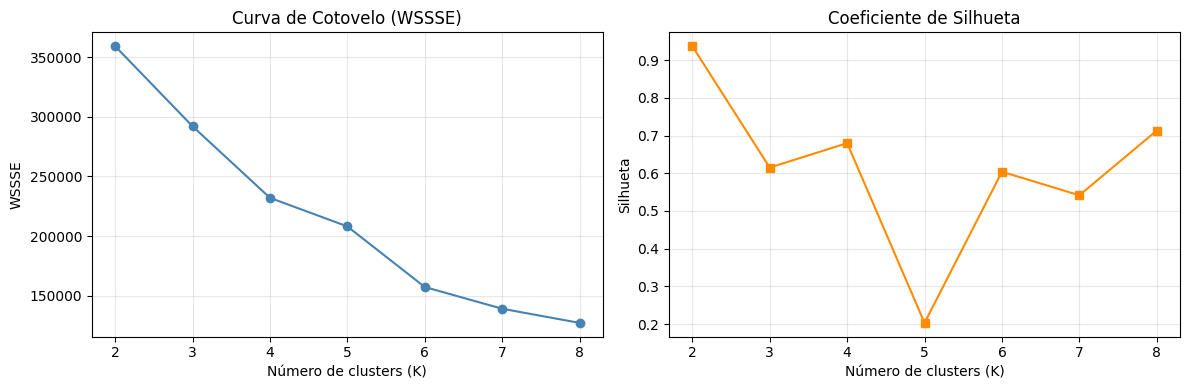

Gráfico salvo em models/kmeans_k_selection.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow curve 
axes[0].plot(df_k['k'], df_k['WSSSE'], marker='o', color='steelblue')
axes[0].set_title('Curva de Cotovelo (WSSSE)')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('WSSSE')
axes[0].grid(True, alpha=0.3)

# Silhouette 
axes[1].plot(df_k['k'], df_k['Silhueta'], marker='s', color='darkorange')
axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhueta')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em models/kmeans_k_selection.png')



| k | WSSSE | Silhouette |
|---|---|---|
| 2 | 462,072 | 0.913 |
| 4 | 335,268 | 0.598 |
| **5** | **318,455** | **0.799** |
| 6 | 258,797 | 0.780 |

K=5, melhoria significativa no WSSSE em relação a k=4, e silhueta retorna a 0,799.
Os 5 clusters se alinham com os 5 perfis de atraso esperados (cascata, operacional, meteorológico, espaço aéreo, misto).

In [12]:
K_OPTIMAL = 5

print(f'Training KMeans with K={K_OPTIMAL} on full dataset...')

kmeans_final = KMeans(
    featuresCol='features',
    k=K_OPTIMAL,
    seed=42,
    maxIter=50,
    tol=1e-4
)

model_kmeans = kmeans_final.fit(df_scaled)
df_clustered = model_kmeans.transform(df_scaled)
df_clustered.cache()

print(f'Done  |  WSSSE = {model_kmeans.summary.trainingCost:,.2f}')

print('\nCluster distribution:')
df_clustered.groupBy('prediction').count()\
    .withColumn('PCT', F.round(F.col('count') / n_delayed * 100, 2))\
    .orderBy('prediction').show()

Training KMeans with K=5 on full dataset...
Done  |  WSSSE = 2,127,273.79

Cluster distribution:


+----------+------+-----+
|prediction| count|  PCT|
+----------+------+-----+
|         0|847633|79.71|
|         1| 88474| 8.32|
|         2| 10122| 0.95|
|         3|110998|10.44|
|         4|  6212| 0.58|
+----------+------+-----+



## Interpretação dos Clusters

O perfil de cada cluster é determinado pela **média dos minutos de atraso
por causa**. A causa com maior valor médio define o caráter do grupo.

In [13]:
perfil = (
    df_clustered
    .groupBy('prediction')
    .agg(
        F.count('*').alias('N_VOOS'),
        F.round(F.mean('ARRIVAL_DELAY'), 1).alias('ATRASO_MEDIO_MIN'),
        *[F.round(F.mean(c), 1).alias(c) for c in FEATURES_CLUSTER]
    )
    .orderBy('prediction')
    .toPandas()
)

perfil['CAUSA_DOMINANTE'] = perfil[FEATURES_CLUSTER].idxmax(axis=1)

print('Perfil dos clusters:')
print(perfil.to_string(index=False))


Perfil dos clusters:
 prediction  N_VOOS  ATRASO_MEDIO_MIN  AIR_SYSTEM_DELAY  AIRLINE_DELAY  LATE_AIRCRAFT_DELAY  WEATHER_DELAY     CAUSA_DOMINANTE
          0  847633              38.7              15.7            8.7                 12.6            1.5    AIR_SYSTEM_DELAY
          1   88474             113.0               3.5          104.8                  4.6            0.1       AIRLINE_DELAY
          2   10122             192.4              14.3            1.5                 11.6          165.0       WEATHER_DELAY
          3  110998             136.4               4.7            6.9                123.2            1.5 LATE_AIRCRAFT_DELAY
          4    6212             449.8               4.9          435.2                  9.6            0.2       AIRLINE_DELAY


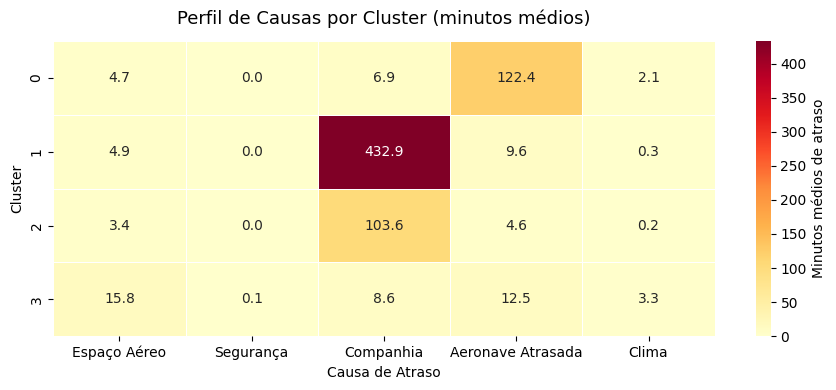

Heatmap salvo em models/kmeans_cluster_heatmap.png


In [11]:
causa_labels = {
    'AIR_SYSTEM_DELAY'   : 'Airspace',
    'AIRLINE_DELAY'      : 'Airline',
    'LATE_AIRCRAFT_DELAY': 'Late Aircraft',
    'WEATHER_DELAY'      : 'Weather',
}

heatmap_data = (
    perfil
    .set_index('prediction')[FEATURES_CLUSTER]
    .rename(columns=causa_labels)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg delay minutes'}
)
ax.set_title('Delay Cause Profile per Cluster (avg minutes)', fontsize=13, pad=12)
ax.set_xlabel('Delay Cause')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../models/kmeans_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
airline_cluster = (
    df_clustered
    .groupBy('AIRLINE', 'prediction')
    .count()
    .withColumnRenamed('count', 'N')
    .toPandas()
    .pivot(index='AIRLINE', columns='prediction', values='N')
    .fillna(0).astype(int)
)

airline_cluster_pct = airline_cluster.div(airline_cluster.sum(axis=1), axis=0).round(3) * 100
airline_cluster_pct.columns = [f'Cluster {c}' for c in airline_cluster_pct.columns]

print('% dos voos atrasados de cada companhia por cluster:')
print(airline_cluster_pct.to_string())


% dos voos atrasados de cada companhia por cluster:
         Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4
AIRLINE                                                       
AA            79.7        8.9        1.2        9.5        0.7
AS            83.8        7.8        0.6        7.4        0.4
B6            80.3        7.9        0.7       10.8        0.3
DL            80.3        9.2        1.5        7.8        1.2
EV            76.8       10.5        0.6       11.4        0.8
F9            82.1        5.3        0.3       11.7        0.6
HA            89.0        6.3        0.1        3.9        0.7
MQ            79.7        7.5        2.1       10.0        0.6
NK            82.9        5.6        0.5       10.8        0.3
OO            76.3        9.5        0.8       12.6        0.8
UA            77.2        8.9        0.9       12.6        0.4
US            84.5        8.7        0.7        5.8        0.3
VX            85.0        4.9        0.2        9.7        0.2
WN 

## Persistência do Modelo

Dois artefatos são salvos:
- **`models/kmeans`**: pipeline completo (KMeans) — usado para inferência em novos dados
- **`models/kmeans_preprocessor`**: pipeline de pré-processamento (assembler + scaler)
  — necessário para transformar novos dados antes de passar pelo modelo

In [15]:
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

prep_model.write().overwrite().save(f'{MODELS_DIR}/kmeans_preprocessor')
print(f'✅ Pré-processador salvo em {MODELS_DIR}/kmeans_preprocessor')

# KMeans model
model_kmeans.write().overwrite().save(f'{MODELS_DIR}/kmeans')
print(f'✅ Modelo KMeans  salvo em {MODELS_DIR}/kmeans')

print(f'\nK utilizado       : {K_OPTIMAL}')
print(f'WSSSE final       : {model_kmeans.summary.trainingCost:,.2f}')
print(f'Voos agrupados    : {n_delayed:,}')
print(f'\nArtefatos salvos com sucesso ✅')


✅ Pré-processador salvo em ../models/kmeans_preprocessor
✅ Modelo KMeans  salvo em ../models/kmeans

K utilizado       : 5
WSSSE final       : 2,127,273.79
Voos agrupados    : 1,063,439

Artefatos salvos com sucesso ✅
